In [26]:
import pandas as pd
import numpy as np
import statsmodels.api as sm
import statsmodels.tsa.stattools as ts
from statsmodels.graphics.tsaplots import plot_acf, plot_pacf
from pandas.plotting import lag_plot

In [5]:
# non-stationary data
df1 = pd.read_csv('../data/airline_passengers.csv', index_col='Month', parse_dates=True)
df1.index.freq = 'MS'

# stationary data
df2 = pd.read_csv('../data/DailyTotalFemaleBirths.csv', index_col='Date', parse_dates=True)
df2.index.freq = 'D'

In [8]:
df = pd.DataFrame({"a":[13, 5, 11, 12, 9]})

ts.acf(df['a']) # autocorrelation function 

array([ 1.   , -0.5  , -0.2  ,  0.275, -0.075])

In [11]:
# partial autocorrelation function using Yule-Walker estimation method and nlags=4 since we have 5 observations
# mle: maximum likelihood estimation. mle in order to used biased ACF coefficients
ts.pacf_yw(df['a'], nlags=4, method='mle')

array([ 1.        , -0.5       , -0.6       , -0.38541667, -0.40563273])

In [ ]:
ts.pacf_yw(df['a'], nlags=4, method='adjusted') # adjusted is the default method and uses unbiased ACF coefficients

array([ 1.        , -0.625     , -1.18803419,  2.03764205,  0.8949589 ])

In [21]:
# partial autocorrelation function using ordinary least squares regression method
ts.pacf_ols(df['a'], nlags=2)

array([ 1.        , -0.49677419, -0.43181818])

<Axes: xlabel='y(t)', ylabel='y(t + 1)'>

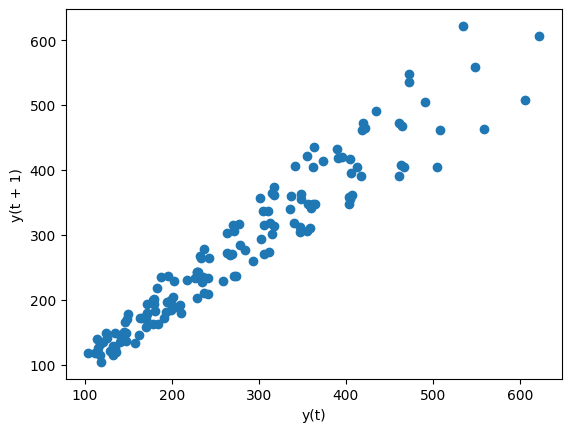

In [ ]:
lag_plot(df1["Thousands of Passengers"])
# we see a correlation meaning that data is non-stationary

<Axes: xlabel='y(t)', ylabel='y(t + 1)'>

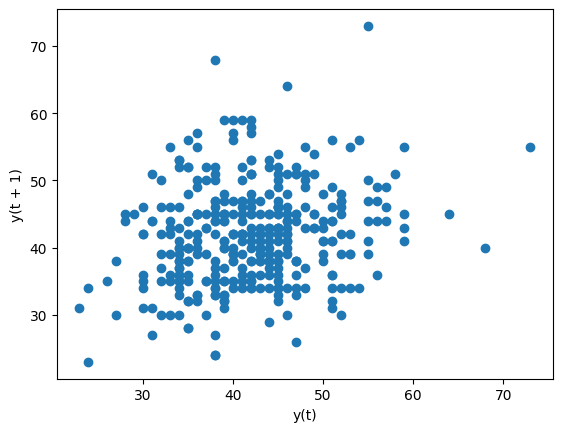

In [ ]:
lag_plot(df2["Births"])
# we dont see a correlation meaning that data is stationary
# which makes sense since the number of births per day should 
# not be affected by the number of births in the previous day

<Axes: xlabel='Month'>

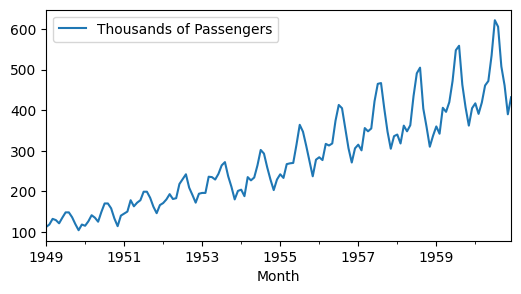

In [28]:
df1.plot(figsize=(6,3))

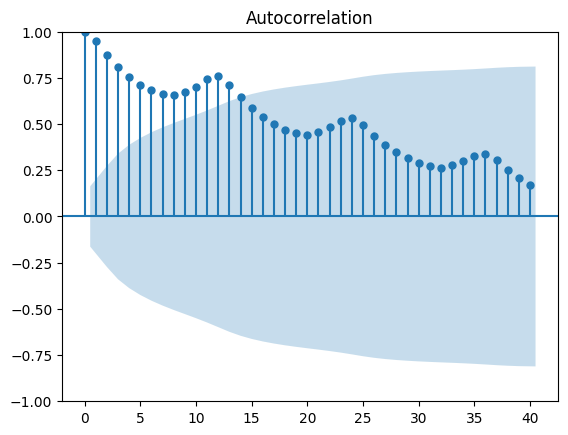

In [ ]:
# lags=40 means that we want to see the correlation of the data with itself up to 40 
plot_acf(df1, lags=40);
# there is clear of seasonality in the data since we see a peak in correlation every 12 months
# the shaded region is the confidence interval. If the correlation is outside of this region then 
# it is statistically significant, meaning that it is unlikely to be due to random chance
# we can see that up to lag 12 the correlation is statistically significant, but after that it is not. 
# This means that the data is correlated with itself up to 12 months, but after that it decays 

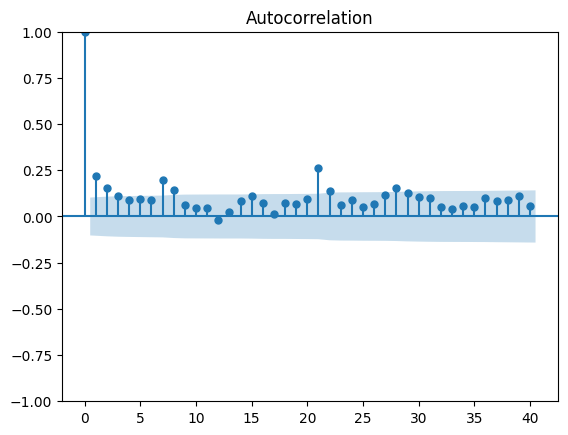

In [ ]:
plot_acf(df2, lags=40);
# there is no clear pattern in the ACF plot, which is what we would expect from stationary data.

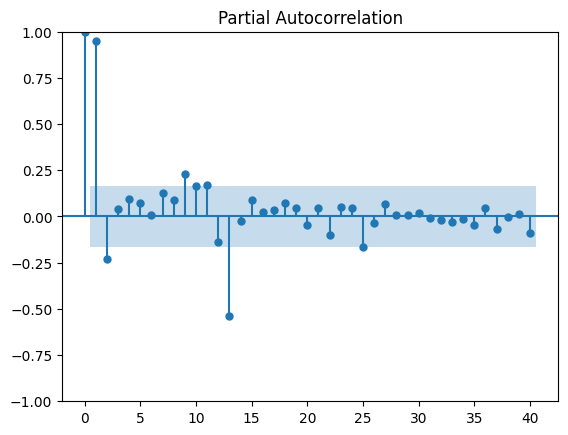

In [38]:
plot_pacf(df1, lags=40);